# Research and Development Notebook
This notebook loads the training data, performs quick EDA, trains a model, and saves it with `joblib` for later import.


In [3]:
# Importing Libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
import joblib

# Libraries Settings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=Warning)


## Load Data


In [4]:
DATA_PATH = "../data/Training Data.csv"  # relative to this notebook
TARGET = "Risk_Flag"

# Load data
# Note: You can change DATA_PATH if your file is elsewhere
_df_path = os.path.normpath(os.path.join(os.getcwd(), DATA_PATH))
df = pd.read_csv(_df_path)

print("Shape:", df.shape)
df.head()


Shape: (252000, 13)


,Id,Income,Age,Experience,marital_status,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


## Quick EDA


In [ ]:
# Basic info
print(df.info())

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values (top):")
print(missing.head(10))




<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Id                 252000 non-null  int64
 1   Income             252000 non-null  int64
 2   Age                252000 non-null  int64
 3   Experience         252000 non-null  int64
 4   marital_status     252000 non-null  str  
 5   House_Ownership    252000 non-null  str  
 6   Car_Ownership      252000 non-null  str  
 7   Profession         252000 non-null  str  
 8   CITY               252000 non-null  str  
 9   STATE              252000 non-null  str  
 10  CURRENT_JOB_YRS    252000 non-null  int64
 11  CURRENT_HOUSE_YRS  252000 non-null  int64
 12  Risk_Flag          252000 non-null  int64
dtypes: int64(7), str(6)
memory usage: 25.0 MB
None
Missing values (top):
Id                 0
Income             0
Age                0
Experience         0
marital_status     0
House_Ownership 

In [6]:
# Duplicates
print("Duplicates:", df.duplicated().sum())

# Summary stats
print("Describe numeric:")
print(df.describe())

Duplicates: 0
Describe numeric:
                  Id        Income            Age     Experience  \
count  252000.000000  2.520000e+05  252000.000000  252000.000000   
mean   126000.500000  4.997117e+06      49.954071      10.084437   
std     72746.278255  2.878311e+06      17.063855       6.002590   
min         1.000000  1.031000e+04      21.000000       0.000000   
25%     63000.750000  2.503015e+06      35.000000       5.000000   
50%    126000.500000  5.000694e+06      50.000000      10.000000   
75%    189000.250000  7.477502e+06      65.000000      15.000000   
max    252000.000000  9.999938e+06      79.000000      20.000000   

       CURRENT_JOB_YRS  CURRENT_HOUSE_YRS      Risk_Flag  
count    252000.000000      252000.000000  252000.000000  
mean          6.333877          11.997794       0.123000  
std           3.647053           1.399037       0.328438  
min           0.000000          10.000000       0.000000  
25%           3.000000          11.000000       0.000000  
5

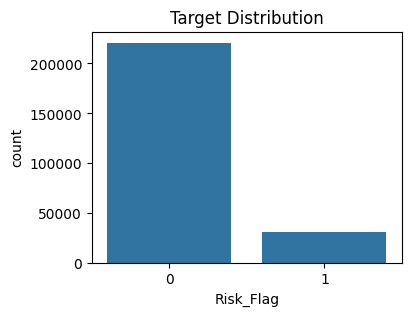

In [7]:
# Target distribution
plt.figure(figsize=(4,3))
sns.countplot(x=TARGET, data=df)
plt.title("Target Distribution")
plt.show()


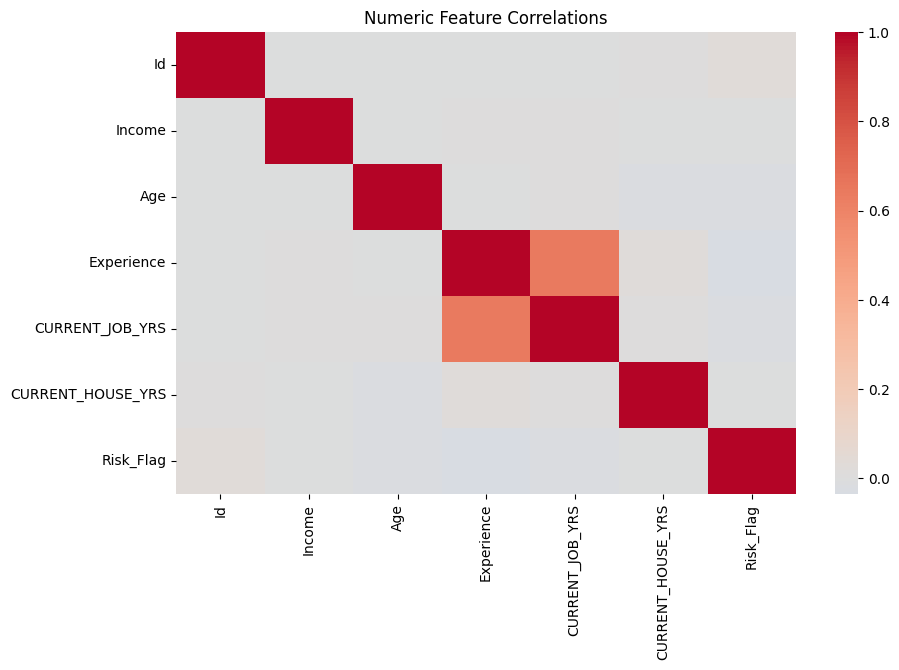

In [8]:
# Correlation heatmap for numeric features
num_cols = df.select_dtypes(include=["number"]).columns
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlations")
plt.show()


## Prepare Features & Split


In [9]:
# Drop identifier if present
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (201600, 11) Test shape: (50400, 11)


## Preprocessing + Model Pipeline


In [10]:
# Identify columns
numeric_features = X.select_dtypes(include=["number"]).columns
categorical_features = X.select_dtypes(exclude=["number"]).columns

# Preprocess numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Model
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
)

clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


## Train & Evaluate


              precision    recall  f1-score   support

           0       0.91      0.57      0.70     44201
           1       0.17      0.61      0.26      6199

    accuracy                           0.57     50400
   macro avg       0.54      0.59      0.48     50400
weighted avg       0.82      0.57      0.65     50400



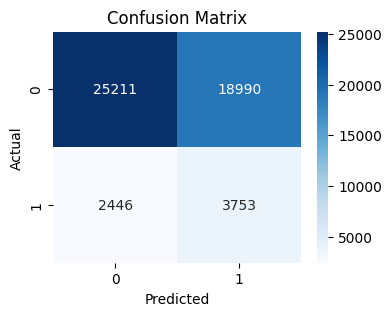

ROC AUC: 0.624167774775979


In [11]:
# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC (only if binary)
if len(np.unique(y_test)) == 2:
    y_proba = clf.predict_proba(X_test)[:, 1]
    print("ROC AUC:", roc_auc_score(y_test, y_proba))


## Save Model with Joblib


In [12]:
MODEL_DIR = "../models"
MODEL_PATH = os.path.normpath(os.path.join(os.getcwd(), MODEL_DIR, "risk_flag_model.joblib"))

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(clf, MODEL_PATH)
print("Saved model to:", MODEL_PATH)


Saved model to: /home/mubarakizzat/BackEnd/ml-fastapi-project/ml_model_package/models/risk_flag_model.joblib


## Quick Inference Example


In [13]:
# Example inference using a single row
sample = X_test.iloc[:1]
print("Sample input:")
print(sample)

pred = clf.predict(sample)
proba = clf.predict_proba(sample)[:, 1] if hasattr(clf, "predict_proba") else None
print("Prediction:", pred)
print("Probability:", proba)


Sample input:
        Income  Age  Experience marital_status House_Ownership Car_Ownership  \
73540  1695876   58           6         single          rented           yes   

                       Profession                  CITY  STATE  \
73540  Computer_hardware_engineer  Bhalswa_Jahangir_Pur  Delhi   

       CURRENT_JOB_YRS  CURRENT_HOUSE_YRS  
73540                6                 13  
Prediction: [0]
Probability: [0.36491816]
